In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, Perceptron
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

In [113]:
df_student = pd.read_csv("StudentPerformanceFactors.csv")
df_student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [114]:
df_student.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### OLS Regression: Predicting Exam Score from numeric features

In [115]:
numeric_cols = df_student.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('Exam_Score')

X_ols = sm.add_constant(df_student[numeric_cols])
y_exam = df_student['Exam_Score']

ols_model = sm.OLS(y_exam, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1638.
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:58:48   Log-Likelihood:                -15338.
No. Observations:                6607   AIC:                         3.069e+04
Df Residuals:                    6600   BIC:                         3.074e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                40.9271      0.33

### Lasso Regression: Using L1 regularization for variable selection

In [116]:
scaler = StandardScaler()
X_lasso = scaler.fit_transform(df_student[numeric_cols])

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_lasso, y_exam)

print(f"Best alpha (CV): {lasso.alpha_:.6f}\n")
print("Lasso coefficients:")
for name, coef in zip(numeric_cols, lasso.coef_):
    print(f"  {name:<20}: {coef:+.4f}")

Best alpha (CV): 0.003950

Lasso coefficients:
  Hours_Studied       : +1.7426
  Attendance          : +2.2819
  Sleep_Hours         : -0.0227
  Previous_Scores     : +0.6890
  Tutoring_Sessions   : +0.6034
  Physical_Activity   : +0.1445


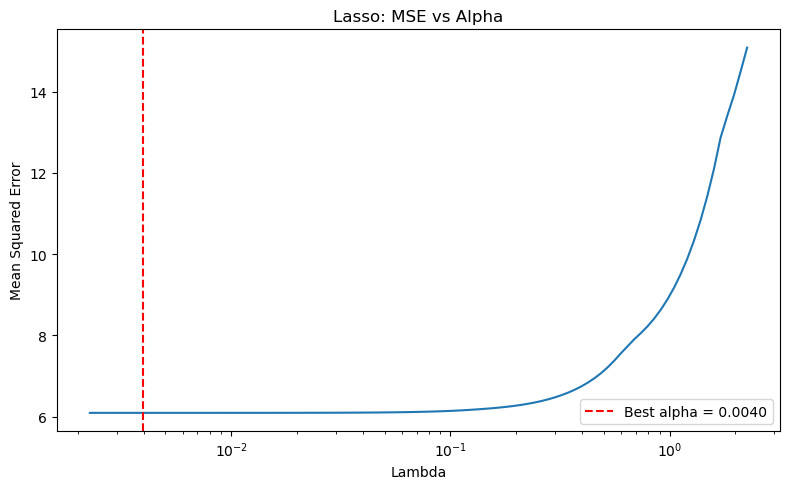

In [117]:
plt.figure(figsize=(8, 5))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.axvline(lasso.alpha_, color='r', linestyle='--', label=f'Best alpha = {lasso.alpha_:.4f}')
plt.xlabel('Lambda')
plt.ylabel('Mean Squared Error')
plt.title('Lasso: MSE vs Alpha')
plt.xscale('log')
plt.legend()
plt.tight_layout()
plt.show()

### Classification: Predicting School Type (Public vs Private)

Shifting from regression to classification

In [118]:
le = LabelEncoder()
y_school = le.fit_transform(df_student['School_Type'])

X_clf = StandardScaler().fit_transform(df_student.select_dtypes(include='number'))
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_school, test_size=0.2, random_state=42)

# Perceptron baseline
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)

print(f"Perceptron train acc: {perceptron.score(X_train, y_train):.4f}")
print(f"Perceptron test acc:  {perceptron.score(X_test, y_test):.4f}")

Perceptron train acc: 0.6403
Perceptron test acc:  0.6430


### Random Forest with Stratified Cross-Validation

In [119]:
X_rf = df_student.select_dtypes(include='number')

rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_rf, y_school, cv=cv, scoring='accuracy')

print("Fold accuracies:", [f"{s:.4f}" for s in cv_scores])
print(f"Mean CV accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Fold accuracies: ['0.6740', '0.6732', '0.6715', '0.6639', '0.6669']
Mean CV accuracy: 0.6699 (+/- 0.0039)


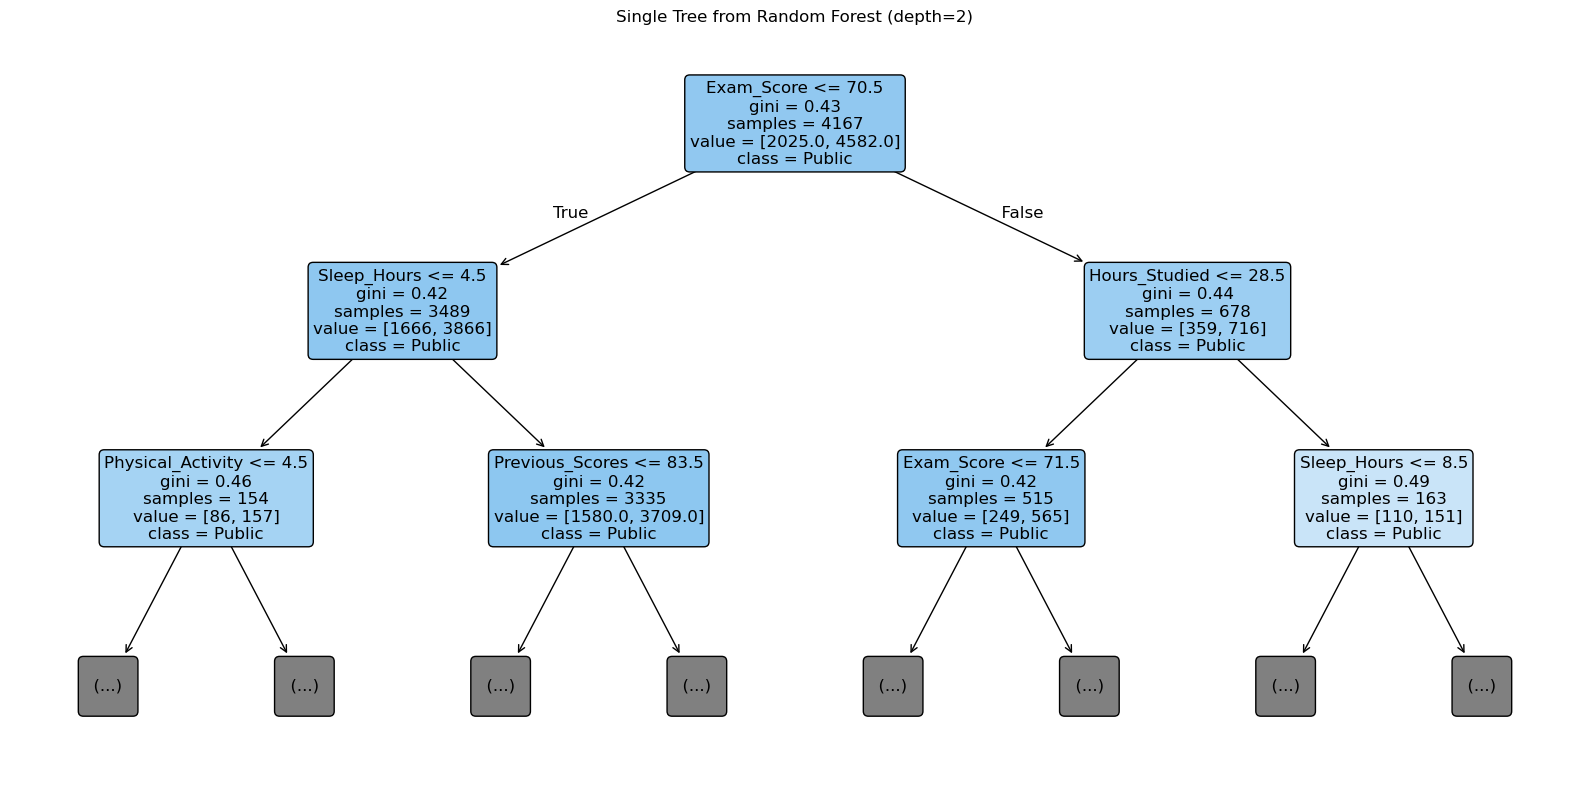

In [120]:
rf_fitted = RandomForestClassifier(random_state=42)
rf_fitted.fit(X_rf, y_school)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    rf_fitted.estimators_[0],
    feature_names=X_rf.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=2,
    fontsize=12,
    rounded=True,
    precision=2,
    ax=ax
)
ax.set_title("Single Tree from Random Forest (depth=2)")
plt.tight_layout()
plt.show()